# Do law professors teach what they believe?

This notebook starts from the raw SPSS survey file, extracts the judge-view variables and their value labels, and then plots row-percentage heatmaps comparing personal views with teaching characterizations.

The SPSS file includes variable labels and value labels for the variables used here. The extraction cell below writes a small codebook CSV for the plotted variables so the labels are visible outside SPSS.


In [1]:
from pathlib import Path
import subprocess

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

RAW_DATA_CANDIDATES = [
    Path("data/Law Faculty 2026-internal use.sav"),
    Path("Downloads/Law Faculty 2026-internal use.sav"),
    Path("../Downloads/Law Faculty 2026-internal use.sav"),
]

RAW_DATA_PATH = next((path for path in RAW_DATA_CANDIDATES if path.exists()), None)
if RAW_DATA_PATH is None:
    searched = "\n".join(str(path) for path in RAW_DATA_CANDIDATES)
    raise FileNotFoundError(f"Could not find the raw SAV file. Looked in:\n{searched}")

OUTPUT_DIR = Path("law_faculty_judges_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

HEATMAP_CELLS_PATH = OUTPUT_DIR / "judges_row_heatmap_core_cells.csv"
CODEBOOK_PATH = OUTPUT_DIR / "law_faculty_judges_codebook.csv"
EXTRACT_SCRIPT_PATH = OUTPUT_DIR / "extract_law_faculty_judges.R"

RAW_DATA_PATH
'''
    )
)

cells.append(
    code_cell(
        r'''
r_extract_code = r'''
suppressPackageStartupMessages({
  library(foreign)
})

args <- commandArgs(trailingOnly = TRUE)
in_sav <- args[[1]]
cells_out <- args[[2]]
codebook_out <- args[[3]]

txt <- function(x) trimws(as.character(x))

dat_lbl <- read.spss(in_sav, to.data.frame = TRUE, use.value.labels = TRUE)
dat_num <- read.spss(in_sav, to.data.frame = TRUE, use.value.labels = FALSE)
var_labels <- attr(dat_lbl, "variable.labels")

get_level_order <- function(var_name) {
  lev <- data.frame(
    code = dat_num[[var_name]],
    label = txt(dat_lbl[[var_name]]),
    stringsAsFactors = FALSE
  )
  lev <- lev[!is.na(lev$code) & !is.na(lev$label) & lev$label != "", ]
  lev <- lev[!duplicated(lev[, c("code", "label")]), ]
  lev <- lev[order(lev$code), ]
  lev
}

vars_for_codebook <- c("judgeview", "judgeteach", "Gender")
codebook <- do.call(
  rbind,
  lapply(vars_for_codebook, function(var_name) {
    lev <- get_level_order(var_name)
    data.frame(
      variable = var_name,
      variable_label = unname(var_labels[var_name]),
      value_code = lev$code,
      value_label = lev$label,
      stringsAsFactors = FALSE
    )
  })
)
write.csv(codebook, codebook_out, row.names = FALSE, na = "")

judgeview_levels <- get_level_order("judgeview")$label
judgeteach_levels <- get_level_order("judgeteach")$label
spectrum_levels <- intersect(judgeview_levels, judgeteach_levels)
spectrum_levels <- spectrum_levels[grepl("politically motivated|politically neutral", spectrum_levels)]
spectrum_levels <- spectrum_levels[!grepl("don.t know|unsure|don.t characterize|either politically", spectrum_levels, ignore.case = TRUE)]

build_mats <- function(idx, spectrum_only = FALSE) {
  rv <- txt(dat_lbl$judgeview[idx])
  tv <- txt(dat_lbl$judgeteach[idx])

  keep <- !is.na(rv) & !is.na(tv) & rv != "" & tv != ""
  rv <- rv[keep]
  tv <- tv[keep]

  if (spectrum_only) {
    keep_spectrum <- rv %in% spectrum_levels & tv %in% spectrum_levels
    rv <- rv[keep_spectrum]
    tv <- tv[keep_spectrum]
    rv <- factor(rv, levels = spectrum_levels)
    tv <- factor(tv, levels = spectrum_levels)
  } else {
    rv <- factor(rv, levels = judgeview_levels)
    tv <- factor(tv, levels = judgeteach_levels)
  }

  counts <- as.matrix(table(rv, tv, useNA = "no"))
  row_tot <- rowSums(counts)
  col_tot <- colSums(counts)

  if (all(row_tot == 0) || all(col_tot == 0)) {
    stop("No non-missing data in subset.")
  }

  counts <- counts[row_tot > 0, col_tot > 0, drop = FALSE]
  row_tot <- rowSums(counts)
  pct <- sweep(counts, 1, row_tot, "/", check.margin = FALSE) * 100

  list(counts = counts, pct = pct, n = sum(counts))
}

matrix_to_long <- function(name, idx, spectrum_only = FALSE) {
  mats <- build_mats(idx, spectrum_only = spectrum_only)
  row_idx <- seq_len(nrow(mats$counts))
  col_idx <- seq_len(ncol(mats$counts))
  grid <- expand.grid(
    row_index = row_idx,
    col_index = col_idx,
    KEEP.OUT.ATTRS = FALSE
  )
  row_totals <- rowSums(mats$counts)

  data.frame(
    group = name,
    spectrum = if (spectrum_only) "spectrum_only" else "all_responses",
    judgeview = rownames(mats$counts)[grid$row_index],
    judgeteach = colnames(mats$counts)[grid$col_index],
    n = as.integer(mats$counts[cbind(grid$row_index, grid$col_index)]),
    pct = as.numeric(mats$pct[cbind(grid$row_index, grid$col_index)]),
    row_total = as.integer(row_totals[grid$row_index]),
    group_n = mats$n,
    row_order = grid$row_index,
    col_order = grid$col_index,
    stringsAsFactors = FALSE
  )
}

n_all <- nrow(dat_lbl)
idx_all <- rep(TRUE, n_all)
idx_male <- txt(dat_lbl$Gender) == "Male"
idx_female <- txt(dat_lbl$Gender) == "Female"

core_cells <- do.call(
  rbind,
  list(
    matrix_to_long("Overall", idx_all),
    matrix_to_long("Male", idx_male),
    matrix_to_long("Female", idx_female),
    matrix_to_long("Overall", idx_all, spectrum_only = TRUE),
    matrix_to_long("Male", idx_male, spectrum_only = TRUE),
    matrix_to_long("Female", idx_female, spectrum_only = TRUE)
  )
)
write.csv(core_cells, cells_out, row.names = FALSE, na = "")
'''

EXTRACT_SCRIPT_PATH.write_text(r_extract_code)
result = subprocess.run(
    ["Rscript", str(EXTRACT_SCRIPT_PATH), str(RAW_DATA_PATH), str(HEATMAP_CELLS_PATH), str(CODEBOOK_PATH)],
    check=True,
    capture_output=True,
    text=True,
)

if result.stdout.strip():
    print(result.stdout)
if result.stderr.strip():
    print(result.stderr)

heatmap_cells = pd.read_csv(HEATMAP_CELLS_PATH)
codebook = pd.read_csv(CODEBOOK_PATH)

print(f"Raw data: {RAW_DATA_PATH}")
print(f"Extracted heatmap cells: {HEATMAP_CELLS_PATH}")
print(f"Extracted codebook: {CODEBOOK_PATH}")


Warning messages:
1: In read.spss(in_sav, to.data.frame = TRUE, use.value.labels = TRUE) :
  data/Law Faculty 2026-internal use.sav: Very long string record(s) found (record type 7, subtype 14), each will be imported in consecutive separate variables
2: In read.spss(in_sav, to.data.frame = TRUE, use.value.labels = TRUE) :
  data/Law Faculty 2026-internal use.sav: Long string value labels record found (record type 7, subtype 21), but ignored
Warning messages:
1: In read.spss(in_sav, to.data.frame = TRUE, use.value.labels = FALSE) :
  data/Law Faculty 2026-internal use.sav: Very long string record(s) found (record type 7, subtype 14), each will be imported in consecutive separate variables
2: In read.spss(in_sav, to.data.frame = TRUE, use.value.labels = FALSE) :
  data/Law Faculty 2026-internal use.sav: Long string value labels record found (record type 7, subtype 21), but ignored

Raw data: data/Law Faculty 2026-internal use.sav
Extracted heatmap cells: law_faculty_judges_outputs/judges

In [2]:
summary = (
    heatmap_cells[["group", "spectrum", "group_n"]]
    .drop_duplicates()
    .sort_values(["spectrum", "group"])
    .reset_index(drop=True)
)
summary


,group,spectrum,group_n
0,Female,all_responses,541
1,Male,all_responses,977
2,Overall,all_responses,1649
3,Female,spectrum_only,387
4,Male,spectrum_only,787
5,Overall,spectrum_only,1266


In [3]:
codebook


,variable,variable_label,value_code,value_label
0,judgeview,How do you personally view judges’ decision ma...,1,Judges are entirely politically motivated.
1,judgeview,How do you personally view judges’ decision ma...,2,Judges are mostly politically motivated.
2,judgeview,How do you personally view judges’ decision ma...,3,Judges are a mix of politically motivated and ...
3,judgeview,How do you personally view judges’ decision ma...,4,Judges are mostly politically neutral.
4,judgeview,How do you personally view judges’ decision ma...,5,Judges are completely politically neutral.
5,judgeview,How do you personally view judges’ decision ma...,6,Don’t know / unsure.
6,judgeteach,"In your teaching, how do you generally charact...",1,Judges are entirely politically motivated.
7,judgeteach,"In your teaching, how do you generally charact...",2,Judges are mostly politically motivated.
8,judgeteach,"In your teaching, how do you generally charact...",3,Judges are a mix of politically motivated and ...
9,judgeteach,"In your teaching, how do you generally charact...",4,Judges are mostly politically neutral.


In [4]:
FULL_ROW_ORDER = [
    "Judges are entirely politically motivated.",
    "Judges are mostly politically motivated.",
    "Judges are a mix of politically motivated and politically neutral.",
    "Judges are mostly politically neutral.",
    "Judges are completely politically neutral.",
    "Don’t know / unsure.",
]

FULL_COL_ORDER = [
    "Judges are entirely politically motivated.",
    "Judges are mostly politically motivated.",
    "Judges are a mix of politically motivated and politically neutral.",
    "Judges are mostly politically neutral.",
    "Judges are completely politically neutral.",
    "I don’t characterize judges’ decision making as either politically motivated or politically neutral.",
]

SPECTRUM_ORDER = FULL_ROW_ORDER[:5]

DISPLAY_LABELS = {
    "Judges are entirely politically motivated.": "Entirely\npolitical",
    "Judges are mostly politically motivated.": "Mostly\npolitical",
    "Judges are a mix of politically motivated and politically neutral.": "Mixed political\nand neutral",
    "Judges are mostly politically neutral.": "Mostly\nneutral",
    "Judges are completely politically neutral.": "Completely\nneutral",
    "Don’t know / unsure.": "Don’t know\n/ unsure",
    "I don’t characterize judges’ decision making as either politically motivated or politically neutral.": "Do not\ncharacterize",
}

GROUP_LABELS = {
    "Overall": "All faculty",
    "Male": "Men",
    "Female": "Women",
}

SPECTRUM_LABELS = {
    "all_responses": "All responses",
    "spectrum_only": "Political-to-neutral scale only",
}

CHART_TITLE = "Do law professors teach what they believe?"
CREDIT_TEXT = "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 Law Faculty Survey"


def heatmap_matrices(data, group, spectrum):
    sub = data[data["group"].eq(group) & data["spectrum"].eq(spectrum)].copy()
    if sub.empty:
        raise ValueError(f"No rows for group={group}, spectrum={spectrum}")

    row_order = SPECTRUM_ORDER if spectrum == "spectrum_only" else FULL_ROW_ORDER
    col_order = SPECTRUM_ORDER if spectrum == "spectrum_only" else FULL_COL_ORDER

    pct = (
        sub.pivot_table(index="judgeview", columns="judgeteach", values="pct", aggfunc="sum")
        .reindex(index=row_order, columns=col_order)
    )
    counts = (
        sub.pivot_table(index="judgeview", columns="judgeteach", values="n", aggfunc="sum")
        .reindex(index=row_order, columns=col_order)
    )

    labels = pct.copy().astype(object)
    for row in pct.index:
        for col in pct.columns:
            if pd.isna(pct.loc[row, col]):
                labels.loc[row, col] = ""
            else:
                value = pct.loc[row, col]
                count = int(counts.loc[row, col])
                pct_label = "<1%" if 0 < value < 1 else f"{value:.0f}%"
                labels.loc[row, col] = f"{pct_label}\nn={count:,}"

    return pct, labels, int(sub["group_n"].iloc[0])


def plot_judges_heatmap(data, group, spectrum):
    pct, labels, group_n = heatmap_matrices(data, group, spectrum)
    mask = pct.isna()
    n_rows, n_cols = pct.shape

    fig_width = 8.9 if spectrum == "all_responses" else 7.9
    fig_height = 5.7 if spectrum == "all_responses" else 5.15
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    cmap = sns.color_palette("Blues", as_cmap=True)
    sns.heatmap(
        pct,
        ax=ax,
        mask=mask,
        cmap=cmap,
        vmin=0,
        vmax=100,
        linewidths=0.8,
        linecolor="#ffffff",
        annot=labels,
        fmt="",
        annot_kws={"fontsize": 8.5, "linespacing": 1.15},
        cbar_kws={"label": "Percent of row", "shrink": 0.74, "pad": 0.04},
    )

    diagonal_cells = min(5, n_rows, n_cols)
    for idx in range(diagonal_cells):
        if not mask.iloc[idx, idx]:
            ax.add_patch(Rectangle((idx, idx), 1, 1, fill=False, edgecolor="#1f2937", lw=1.8))

    subtitle = f"{GROUP_LABELS[group]} | {SPECTRUM_LABELS[spectrum]} | N={group_n:,} | Each row sums to 100%"
    title_text = CHART_TITLE if group == "Overall" and spectrum == "all_responses" else f"{CHART_TITLE}\n{subtitle}"
    ax.set_title(title_text, loc="left", pad=14, fontsize=13, fontweight="bold")

    ax.set_xlabel("How faculty characterize judges in class", labelpad=12)
    ax.set_ylabel("How faculty personally view judges", labelpad=12)
    ax.set_xticklabels([DISPLAY_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=0, ha="center")
    ax.set_yticklabels([DISPLAY_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()], rotation=0, va="center")
    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("#d1d5db")

    fig.text(
        0.86,
        0.045,
        CREDIT_TEXT,
        ha="right",
        va="bottom",
        fontsize=8.2,
        color="#4b5563",
    )
    fig.tight_layout(rect=[0, 0.075, 1, 1])
    plt.show()


## Original core heatmaps

Includes all valid `judgeview` and `judgeteach` responses.


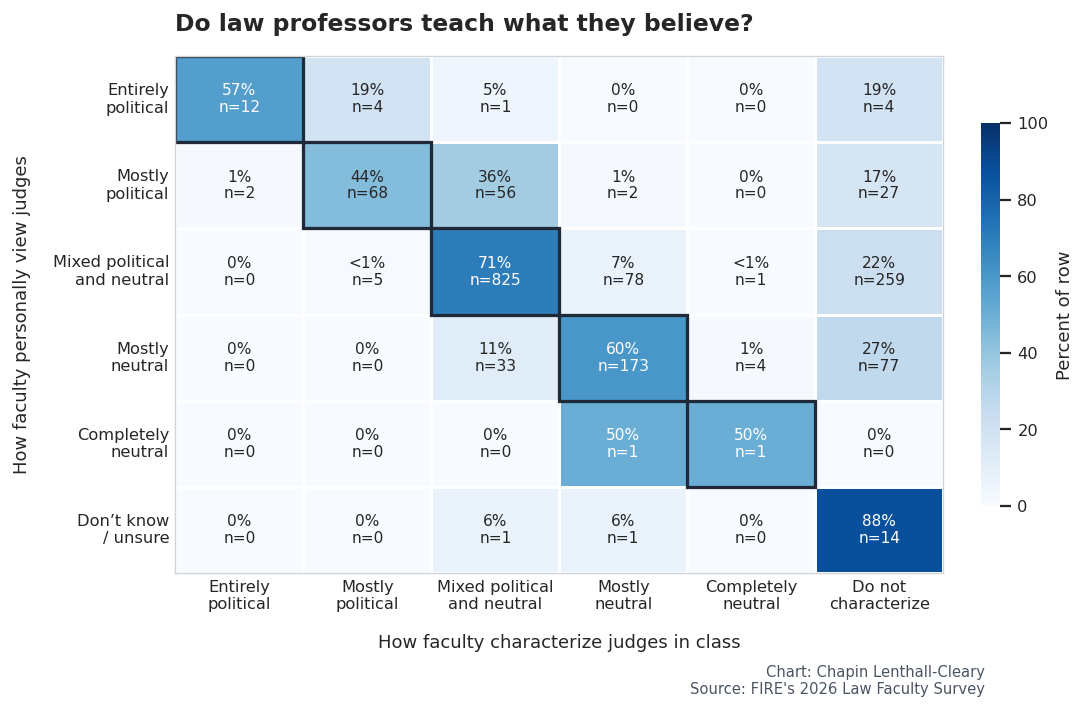

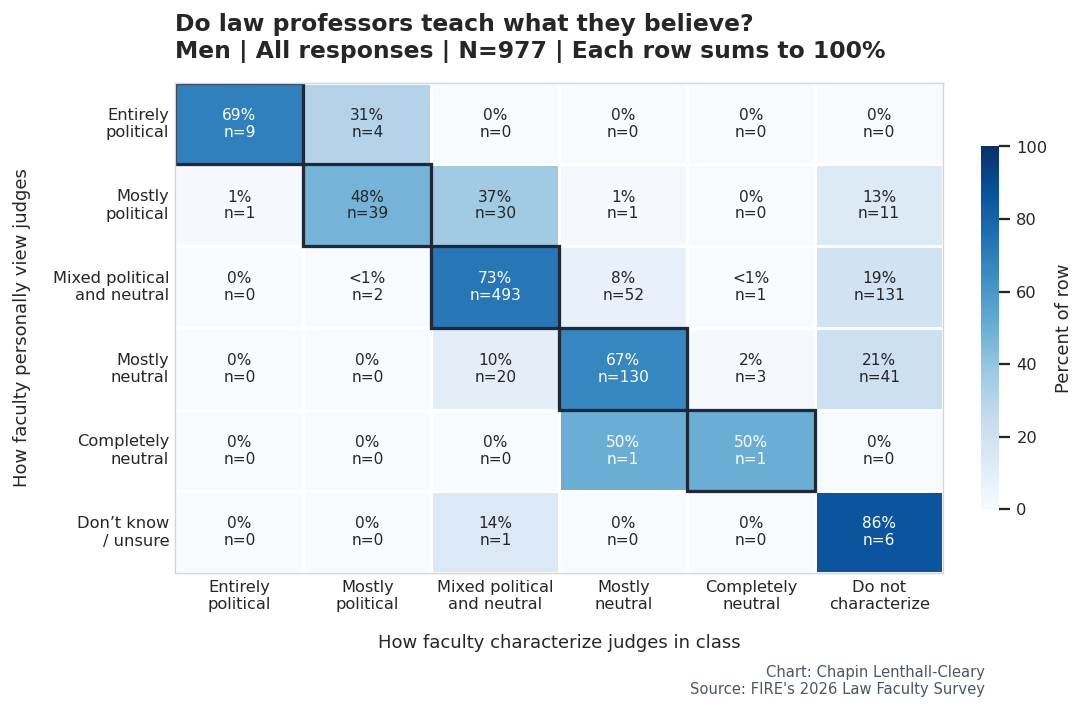

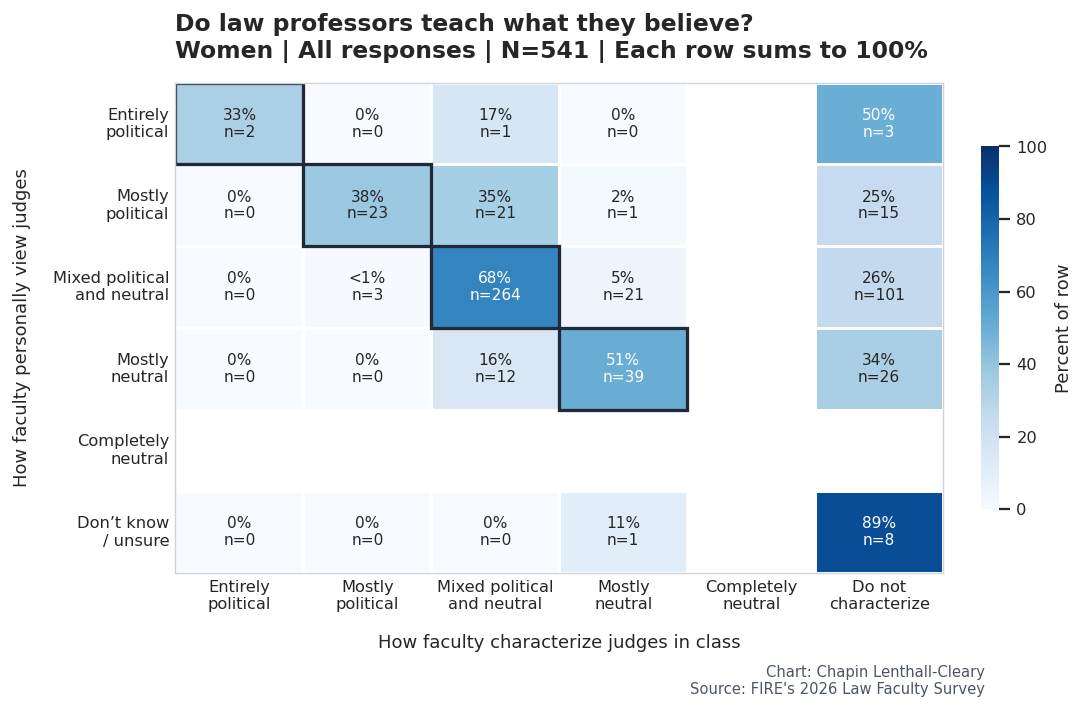

In [5]:
for group in ["Overall", "Male", "Female"]:
    plot_judges_heatmap(heatmap_cells, group, "all_responses")


## Spectrum-only core heatmaps

Excludes answers outside the politically motivated-to-politically neutral scale from both variables, then recalculates row percentages.


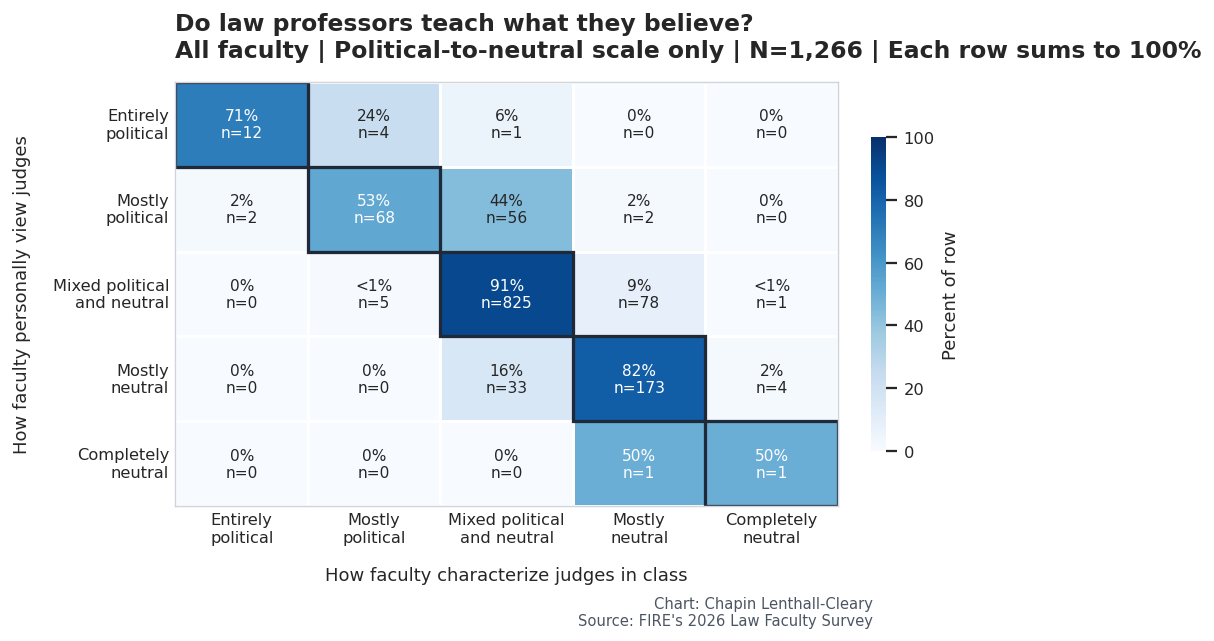

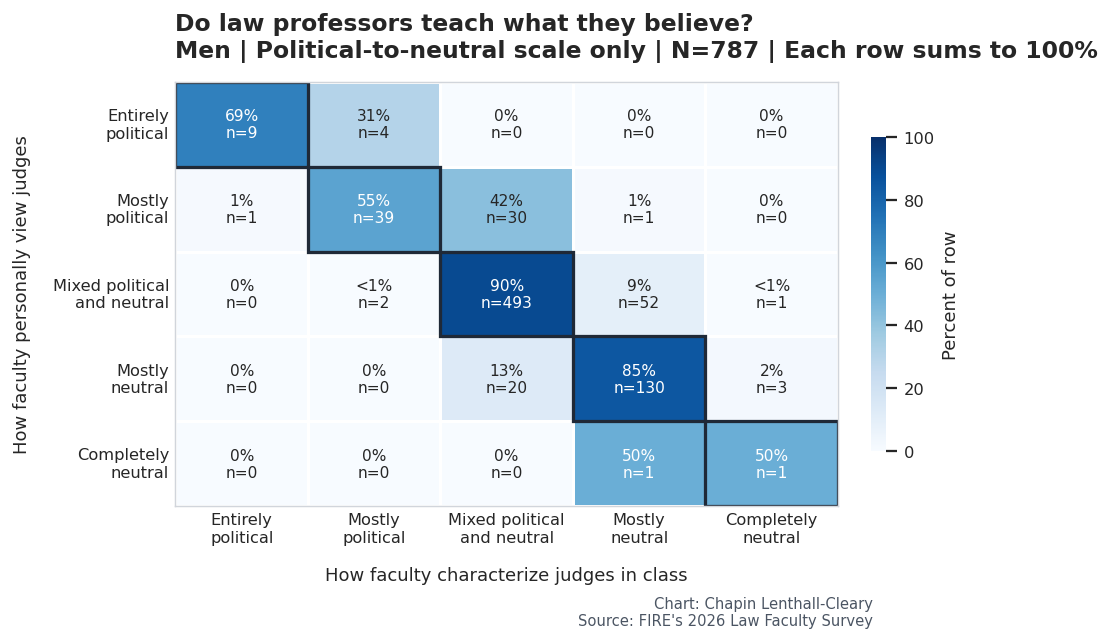

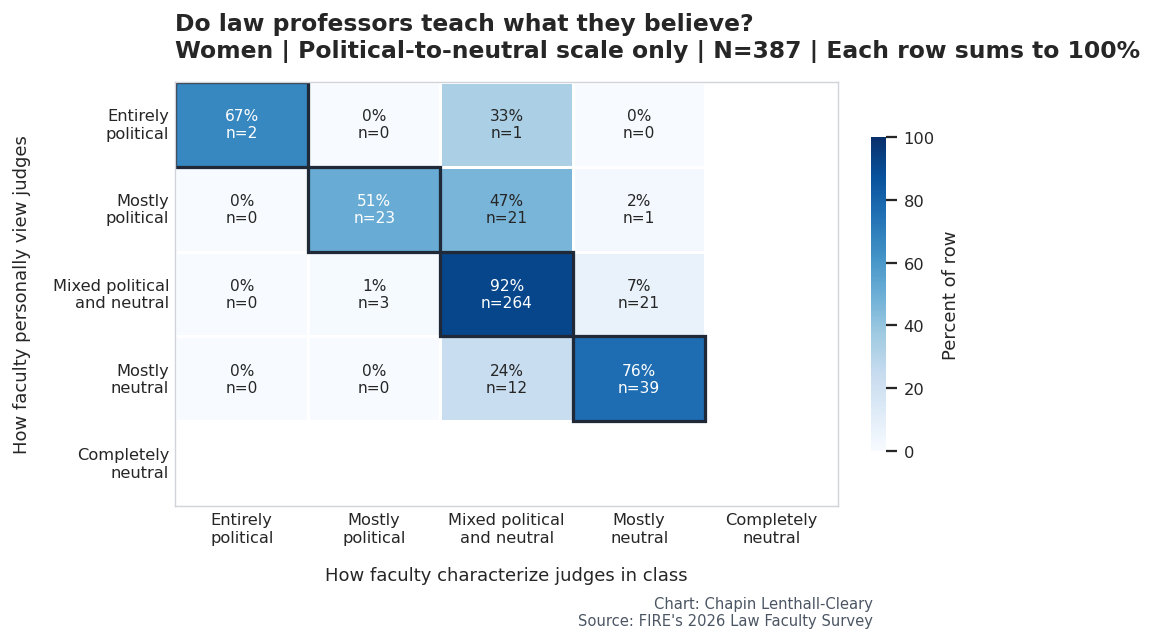

In [6]:
for group in ["Overall", "Male", "Female"]:
    plot_judges_heatmap(heatmap_cells, group, "spectrum_only")
